# 03 — Candidate frontier

The candidate frontier measures how much unique recall Item2Vec contributes when merged with the frozen co-visitation candidate pool.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "reports").exists():
    ROOT = ROOT.parent

def load_json(name):
    return json.loads((ROOT / "reports" / "metrics" / name).read_text())


In [2]:
f = load_json("candidate_frontier.json")
df = pd.DataFrame(f["points"])
df

,item2vec_k,weighted_item2vec_marginal,weighted_union_recall
0,0,0.000000,0.706430
1,20,0.001694,0.708124
2,50,0.003794,0.710224
3,100,0.006398,0.712828
4,150,0.008951,0.715380
5,200,0.010954,0.717384
6,300,0.014407,0.720837
7,400,0.017351,0.723781
8,600,0.021986,0.728416
9,800,0.025773,0.732203


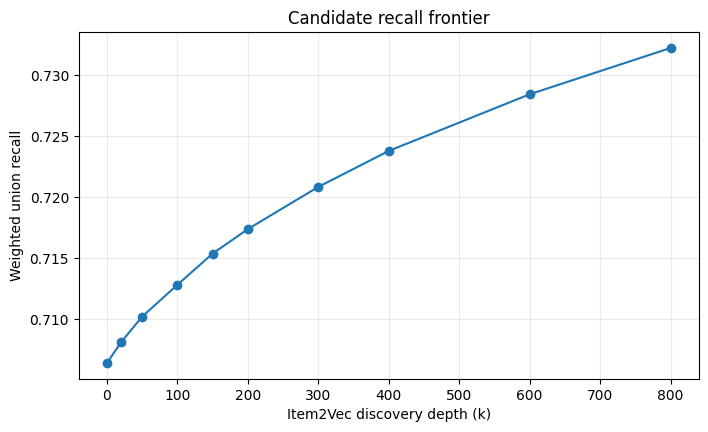

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(df["item2vec_k"], df["weighted_union_recall"], marker="o")
ax.set_xlabel("Item2Vec discovery depth (k)")
ax.set_ylabel("Weighted union recall")
ax.set_title("Candidate recall frontier")
ax.grid(True, alpha=0.25)
plt.show()

In [4]:
df["incremental_gain_per_100_k"] = (
    df["weighted_union_recall"].diff()
    / df["item2vec_k"].diff()
    * 100
)
df[["item2vec_k", "weighted_union_recall", "weighted_item2vec_marginal", "incremental_gain_per_100_k"]]

,item2vec_k,weighted_union_recall,weighted_item2vec_marginal,incremental_gain_per_100_k
0,0,0.706430,0.000000,NaN
1,20,0.708124,0.001694,0.008469
2,50,0.710224,0.003794,0.007000
3,100,0.712828,0.006398,0.005207
4,150,0.715380,0.008951,0.005106
5,200,0.717384,0.010954,0.004006
6,300,0.720837,0.014407,0.003453
7,400,0.723781,0.017351,0.002945
8,600,0.728416,0.021986,0.002317
9,800,0.732203,0.025773,0.001894


### Decision

The frontier is still increasing at k=800, but efficiency declines. The project therefore uses k=800 as a broad discovery pool for hard-negative mining instead of assuming that ~1,000 candidates per session is an efficient final serving budget.